Total Iterations: 5000000
Prime (L) Count: 1102224
Twin Prime Pattern (L-R-L) Count: 518285
Simulated Twin Prime Density: 0.103657
Simulated Prime Density (P(L)): 0.220445
Expected L-R-L (if random): 0.037883
Twin Prime Constant (Structure Factor): 2.7362


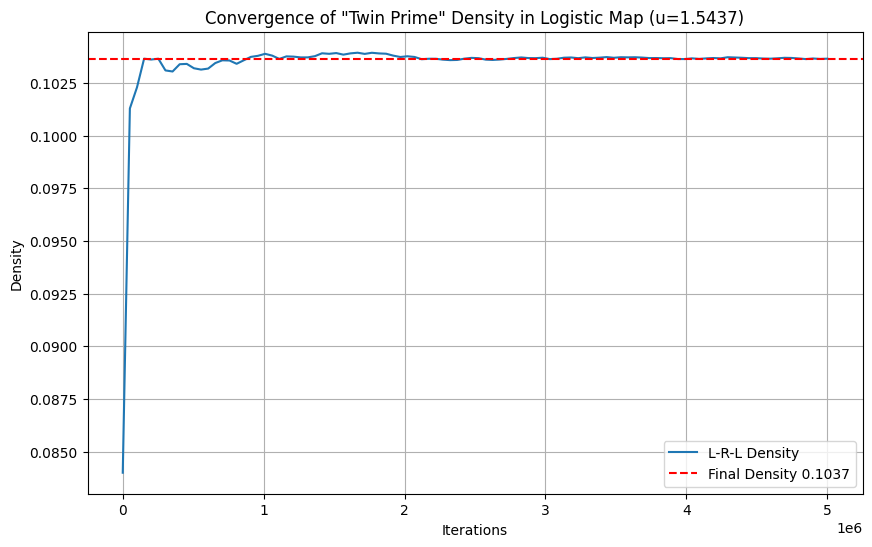

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def logistic_map(x, u):
    return 1 - u * x**2

def run_experiment(n_iterations=10000000):
    # Parameter u taken from the paper edge-of-chaos critical value [cite: 173]
    u = 1.543689012692076
    
    # Initialization
    x = 0.1
    trajectory = []
    
    # For performance one could batch or use numpy; here a simple loop is used for clarity
    # Warm-up to discard transients
    for _ in range(10000):
        x = logistic_map(x, u)
        
    # Generate orbit
    # Generate symbols and additionally count L-R-L patterns
    # L: x < 0, R: x > 0
    
    lrl_count = 0
    l_count = 0
    total_patterns = 0
    
    # History buffer [prev_prev, prev, current]
    # 0 represents L (Prime); 1 represents R (Composite)
    buffer = []
    
    # Record density evolution
    densities = []
    check_points = np.linspace(1000, n_iterations, 100).astype(int)
    
    for i in range(n_iterations):
        x = logistic_map(x, u)
        symbol = 0 if x < 0 else 1 # 0=L, 1=R
        
        if symbol == 0:
            l_count += 1
            
        buffer.append(symbol)
        
        if len(buffer) == 3:
            # Check for the L-R-L pattern (0-1-0)
            if buffer == [0, 1, 0]:
                lrl_count += 1
            buffer.pop(0) # Drop the oldest entry
            
        if (i + 1) in check_points:
            densities.append(lrl_count / (i + 1))

    return lrl_count, l_count, n_iterations, densities

# Run experiment
lrl, l_total, n, densities = run_experiment(n_iterations=5000000)

# Output results
print(f"Total Iterations: {n}")
print(f"Prime (L) Count: {l_total}")
print(f"Twin Prime Pattern (L-R-L) Count: {lrl}")
print(f"Simulated Twin Prime Density: {lrl/n:.6f}")
print(f"Simulated Prime Density (P(L)): {l_total/n:.6f}")

# Reference: if L were random, P(L-R-L) would be P(L)*P(R)*P(L)
p_L = l_total / n
p_R = 1 - p_L
expected_random_lrl = p_L * p_R * p_L
print(f"Expected L-R-L (if random): {expected_random_lrl:.6f}")
print(f"Twin Prime Constant (Structure Factor): {lrl/n / expected_random_lrl:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(np.linspace(0, n, len(densities)), densities, label='L-R-L Density')
plt.axhline(y=lrl/n, color='r', linestyle='--', label=f'Final Density {lrl/n:.4f}')
plt.title(f'Convergence of "Twin Prime" Density in Logistic Map (u={1.5437})')
plt.xlabel('Iterations')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()